# Regiones, Conectividad y Fronteras

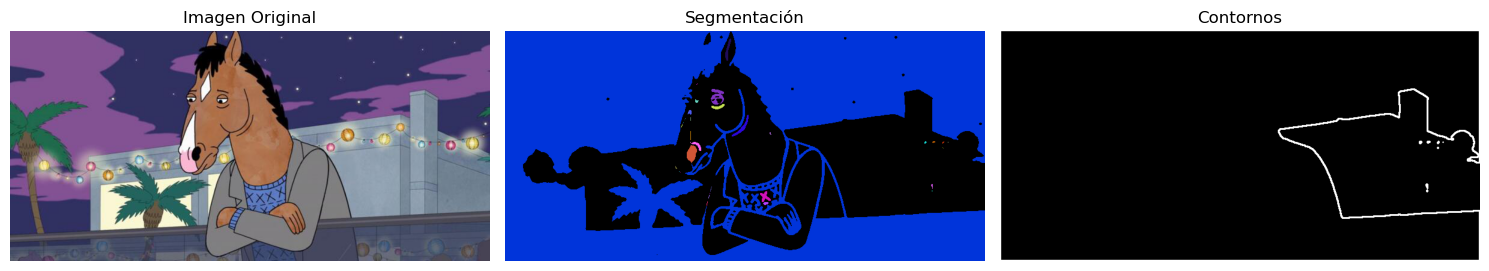

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('./images/img1.jpeg')
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gris, (7, 7), 0)

_, img_bin = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

cantidad, region = cv2.connectedComponents(img_bin)

colores = np.random.randint(0, 255, size=(cantidad, 3), dtype=np.uint8)
colores[0] = [0, 0, 0]
color_regionb = colores[region]

# Fronteras
contorno, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
lineas = cv2.drawContours(np.zeros_like(img_gris), contorno, -1, 255, 2)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(color_regionb)
plt.title('Segmentación')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(lineas, cmap='gray')
plt.title('Contornos')
plt.axis('off')

plt.tight_layout()
plt.show()

# Distancias

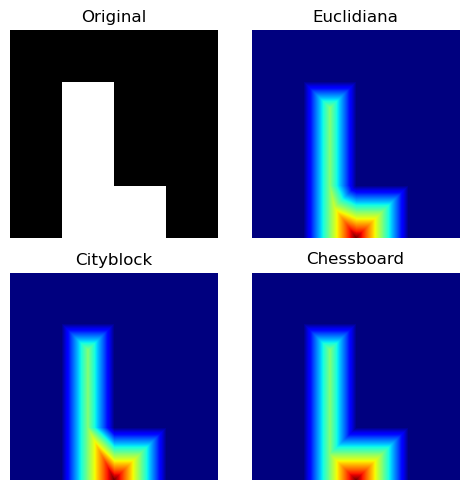

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((200, 200), dtype=np.uint8)
img[50:150, 50:100] = 1
img[150:200, 50:150] = 1

def distancia(img_binarizada):
  invertir = 1 - img_binarizada
  
  # Euclidiana
  dist_eucli = cv2.distanceTransform(img_binarizada, cv2.DIST_L2, 3)
  # Cityblock
  dist_city = cv2.distanceTransform(img_binarizada, cv2.DIST_L1, 3)
  # Chessboard
  dist_chess = cv2.distanceTransform(img_binarizada, cv2.DIST_C, 3)
  
  return dist_eucli, dist_city, dist_chess

eucli, city, chess = distancia(img)

def normalizar(dist):
  return cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

norm_ecli = normalizar(eucli)
norm_city = normalizar(city)
norm_chess = normalizar(chess)

plt.figure(figsize=(5, 5))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(eucli, cmap='jet')
plt.title('Euclidiana')
plt.axis('off')

plt.tight_layout()
plt.show()

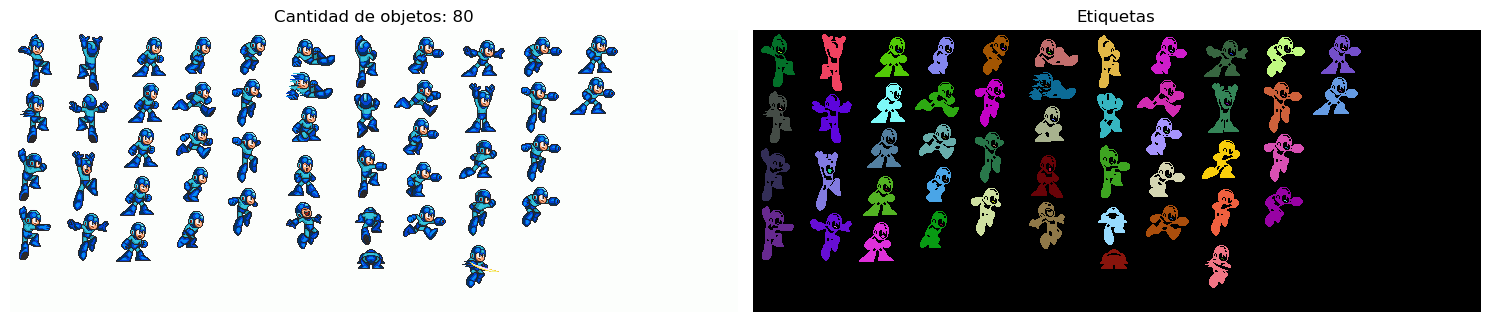

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar(img):
  # Convertir a escala de grises
  gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  # Aplicar umbral
  _, binario = cv2.threshold(gris, 127, 255, cv2.THRESH_BINARY_INV)
  
  # Etiquetar objetos conectados
  # conectividad con 4 = 2; conectividad con 8 = 1
  etiquetas = measure.label(binario, connectivity=2)

  # Contar objetos
  cantidad = np.max(etiquetas)
  return cantidad, etiquetas
  
# img = cv2.imread('./images/img1.jpeg')
img = cv2.imread('./images/sprites.png')

cantidad, etiquetas = contar(img)

def colorear_etiquetas(etiquetas):
    # Crear una imagen RGB vacía
    coloreada = np.zeros((etiquetas.shape[0], etiquetas.shape[1], 3), dtype=np.uint8)
    
    # Generar colores aleatorios para cada etiqueta
    for i in range(1, np.max(etiquetas) + 1):
        # Generar un color aleatorio
        color = np.random.randint(0, 255, 3)
        # Asignar el color a todos los píxeles con esa etiqueta
        coloreada[etiquetas == i] = color
    
    return coloreada

coloreada = colorear_etiquetas(etiquetas)

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f'Cantidad de objetos: {cantidad}')
plt.axis('off')

plt.subplot(1, 2, 2)
# plt.imshow(etiquetas, cmap='gray')
plt.imshow(coloreada)
plt.title('Etiquetas')
plt.axis('off')

plt.tight_layout()
plt.show()

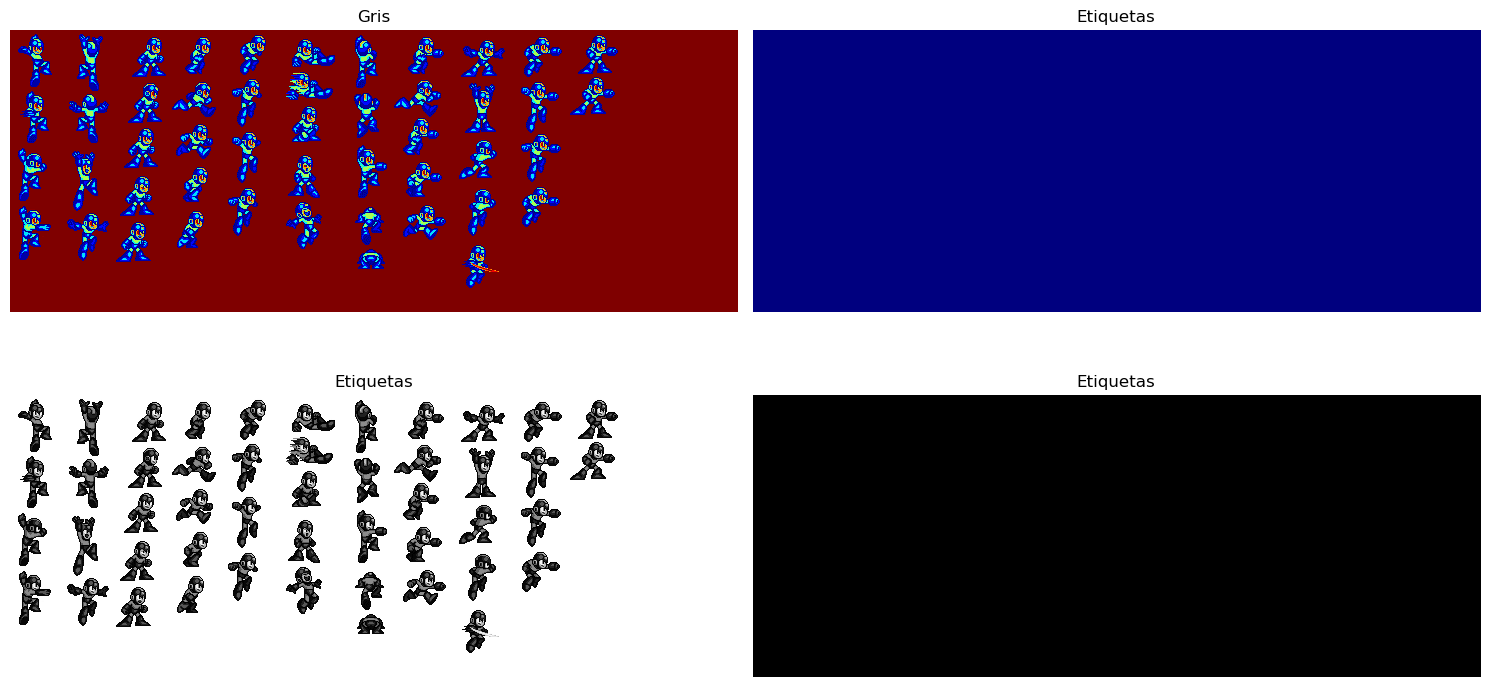

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def etiquetar(img):
  #umbralizado binario
  _, img_binario = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
  # encontrar los contornos
  contorno, _ = cv2.findContours(img_binario, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  img_etiq = np.zeros_like(img, dtype=np.uint8)
  for i, contorno in enumerate(contorno):
    cv2.drawContours(img_etiq, [contorno], -1, (i + 1), -1)
  return img_etiq

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_etiq = etiquetar(img_gray)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_gray, cmap='jet')
plt.title('Gris')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_etiq, cmap='jet')
plt.title('Etiquetas')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_gray, cmap='gray')
plt.title('Etiquetas')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(img_etiq, cmap='gray')
plt.title('Etiquetas')
plt.axis('off')

plt.tight_layout()
plt.show()

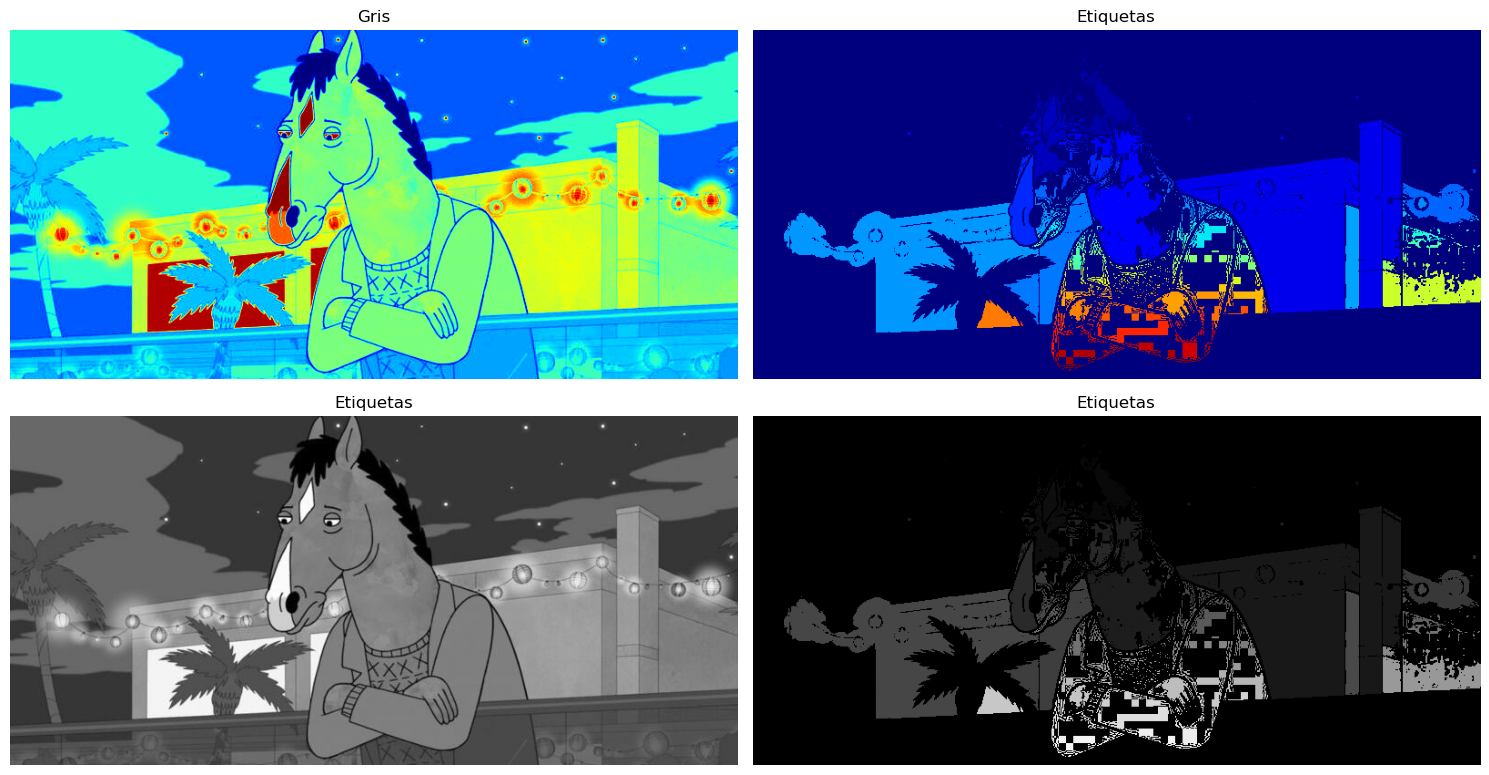

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread('./images/img1.jpeg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, img_bin = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
img_etiq = measure.label(img_bin, connectivity=1)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_gray, cmap='jet')
plt.title('Gris')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_etiq, cmap='jet')
plt.title('Etiquetas')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_gray, cmap='gray')
plt.title('Etiquetas')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(img_etiq, cmap='gray')
plt.title('Etiquetas')
plt.axis('off')

plt.tight_layout()
plt.show()